# Paneles con dataset

El presente archivo utiliza los paneles y el método `pivot.table()` entre otros, para gestionar la información del dataset llamado *"Star dataset to predict star types"*.

## Importación de las librerías necesarias y de los datos

Se importan las librerías `pandas`, `numpy` y `matplotlib.pyplot` con sus alias "pd", "np" y "plt" respectivamente.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Creación del DataFrame con los datos a utilizar como `df`.

In [ ]:
df = pd.read_csv('stars.csv')

## Manejo de los datos (conocimiento del dataset)

En primera instancia vamos a llamar el dataset con el método `.head()` para que, en este caso, nos muestre los primeros diez elementos del dataset.

In [5]:
df.head(10)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
5,2840,0.000650,0.1100,16.98,0,Red,M
6,2637,0.000730,0.1270,17.22,0,Red,M
7,2600,0.000400,0.0960,17.40,0,Red,M
8,2650,0.000690,0.1100,17.45,0,Red,M
9,2700,0.000180,0.1300,16.05,0,Red,M


Conociendo un poco de qué va el dataset, luego usaremos el método `.info()` para que nos entregue información sobre el tipo de dato, si hay o no datos nulos y también la cantidad de elementos incluidas dentro del dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.2+ KB


Tras revisar las columnas que tenemos, una repasada sobre los datos en ellas y también conociendo los tipos de datos que tenemos, hay especial interés en los datos tipo *object* ya que estos pueden tener ciertas variaciones, queriendo decir lo mismo pero escrito de forma diferente. Para ello, usamos el método `.unique()` puesto sobre la columna a analizar, así sabemos que datos son únicos y poder trabajar con ellos.

In [7]:
df['Star color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

Primero se realizó sobre la columna "Star color" y desde ya nos damos cuenta que hay varios datos que significan lo mismo pero están escritos de manera distinta, lo que genera que los datos estén "sucios", por así decirlo.

Para solucionar este problema se utiliza el método `.replace()` que identifican los datos que tienen este comportamiento, se puede hacer una reducción a un nombre común.

In [8]:
# Para las entradas "Orange-Red"
replace_orange_red = ['Red']
to_replace_orange_red = 'Orange-Red'

# Para las entradas "Yellow-White"
replace_yellow_white = ['yellowish','Yellowish','Yellowish White','yellow-white','White-Yellow','Pale yellow orange']
to_replace_yellow_white = 'Yellow-White'

# Para las entradas "White"
replace_white = ['white','Whitish']
to_replace_white = 'White'

# Para las entradas "Blue White"
replace_blue_white = ['Blue white','Blue White','Blue-white','Blue white ']
to_replace_blue_white = 'Blue-White'

# Para las entradas "Blue"
replace_blue = ['Blue ']
to_replace_blue = 'Blue'


df['Star color'] = df['Star color'].replace(
    replace_orange_red, to_replace_orange_red
).replace(
    replace_yellow_white, to_replace_yellow_white
).replace(
    replace_white, to_replace_white
).replace(
    replace_blue_white, to_replace_blue_white
).replace(
    replace_blue, to_replace_blue)

Usamos el método `.unique()` para ver los cambios realizados.

In [9]:
df['Star color'].unique()

array(['Orange-Red', 'Blue-White', 'White', 'Yellow-White', 'Blue',
       'Orange'], dtype=object)

### Primera aplicación del método `.pivot_table()`

Luego de tener las etiquetas para los colores correctas, respecto a su escritura, vamos a realizar la primera tabla dinámica, esta tabla me dirá en promedio cuál es el valor de las diferentes columnas que son números en relación al color que ellas tienen. Para ello se usará el método `.pivot_table()`.

In [10]:
df_panel_color = df.pivot_table(
    index=["Star color"],
    values=["Temperature (K)","Luminosity(L/Lo)","Radius(R/Ro)","Absolute magnitude(Mv)"],
    aggfunc="mean"
)
df_panel_color

,Absolute magnitude(Mv),Luminosity(L/Lo),Radius(R/Ro),Temperature (K)
Star color,,,,
Blue,-2.382446,249974.732446,214.802452,21918.339286
Blue-White,1.968268,68904.416521,185.800842,16659.951220
Orange,-8.625000,590000.000000,1481.500000,4018.000000
Orange-Red,8.142469,59991.158177,281.028340,3307.893805
White,7.486667,78542.975191,211.647388,9579.583333
Yellow-White,6.987750,1.507607,0.757790,7007.687500


Usando un marco de referencia externo, nos damos cuenta que el promedio para las estrellas azules no es correspondiente a la temperatura efectiva real que deben tener las estrellas en su superficie. Sin embargo, los demás promedios están relativamente correctos aunque no es algo de fiar ya que es eso, un promedio, y pueden haber datos los cuales discrepan mucho de las mediciones originales, por lo que realizaremos un diagrama caja-bigote y así analizar mejor los datos.

La tabla de referencia es la siguiente:

| Class | Domination lines | Color        | Color index | Effective temperature | Examples                   |
|-------|------------------|--------------|-------------|-----------------------|----------------------------|
| O     | He II            | Blue         | -0.3        | 28000-50000           | $\chi$ Per, $\epsilon$ Ori |
| B     | He I             | Blue-White   | -0.2        | 9900-28000            | Rigel, Spica               |
| A     | H                | White        | 0.0         | 7400-9900             | Vega, Sirius               |
| F     | Metals; H        | Yellow-White | 0.3         | 6000-7400             | Procyon                    |
| G     | Ca II; Metals    | Yellow       | 0.7         | 4900-6000             | Sun, $\alpha$ Cen A        |
| K     | Ca II; Ca I      | Orange       | 1.2         | 3500-4900             | Arcturus                   |
| M     | TiO; Ca I        | Orange-Red   | 1.4         | 2000-3500             | Betelgeuse                 |

*Tabla tomada del libro "Essential Astrophysics" por Kenneth R. Lang*.

Para realizar el diagrama caja-bigote se tomarán los datos de la temperatura en el eje vertical y los colores correspondientes en el eje horizontal, para ello nos ayudamos de la librería `matplotlib.pyplot` y usando los métodos: `.figure()`, `.boxplot()`, `.xtics()`, `.title()`, `.xlabel()`, `.ylabel()` y `.show()` para configurar y mostrar la figura.

In [11]:
def diagrama_caja_bigote():
    plt.figure(figsize=(10, 6)) # Instancia una figura con un tamaño de (10,6)
    plt.boxplot([df['Temperature (K)'][df['Star color'] == color] for color in df['Star color'].unique()], vert=True) # Genera el gráfico caja-bigote para cada color de estrella tomando los valores únicos
    plt.xticks(range(1, 7), df['Star color'].unique()) # Define la separación del eje x con base en los valores únicos de las estrellas (son 6)
    plt.title('Diagrama de Caja-Bigote de Temperaturas por Colores de las Estrellas') # Título de la figura
    plt.xlabel('Star color') # Leyenda del eje x
    plt.ylabel('Temperature (K)') # Leyenda del eje y
    plt.show() # Muestra la figura

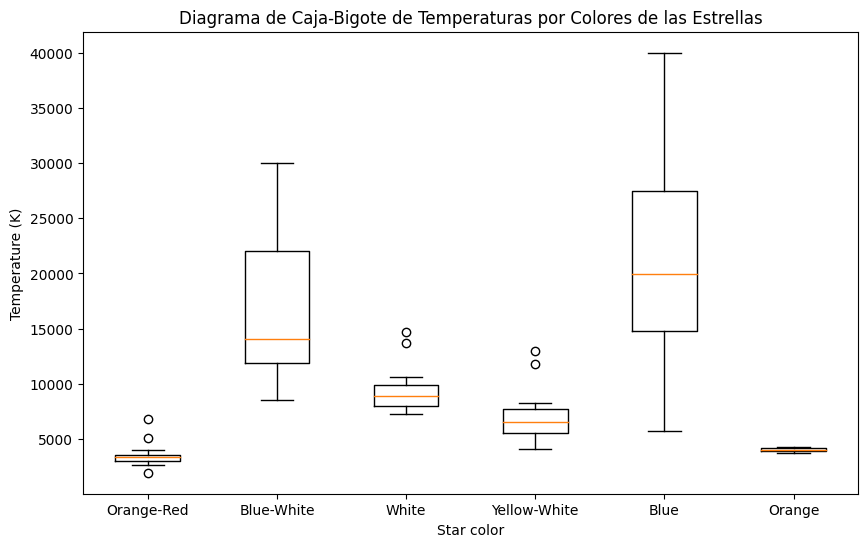

In [12]:
# Llamamos a la función que crea el diagrama
diagrama_caja_bigote()

Tras haber realizado el diagrama caja-bigote correspondiente nos damos cuenta que hay **valores atípicos** para los colores "Orange-Red", "White" y "Yellow-White", sin contar también que los bigotes del color "Blue" son bastante extensos, y que no solo eso sino que tenemos varios valores por fuera del rango definido en la tabla mostrada previamente. También cabe resaltar lo bien ubicados que están los datos para el color "Orange".

### Segunda aplicación del método `.pivot_table()`

Antes de hacer una depuración de los datos que están fuera del rango definido para su temperatura, nos podemos dar cuenta que al revisar la tabla tomada de la literatura, el color no solo es correspondiente con la temperatura sino que también con la clase espectral de las estrellas.

Haremos los mismo pasos anteriores y haremos un análisis de los datos obtenidos.

Primero usaremos el método `.unique()` sobre la columna "Spectral Class" para saber si hay datos repetidos pero con diferente escritura.

In [13]:
df['Spectral Class'].unique()

array(['M', 'B', 'A', 'F', 'O', 'K', 'G'], dtype=object)

Nos damos cuenta que los datos son correctos y correspondientes en cuanto a la escritura, aunque hay algo de notar de una vez, cada clase espectral tiene un color correspondiente, tenemos **siete clases espectrales** y solamente **seis colores** tras la primera depuración. Para poder identificar lo que está sucediendo usamos el método `.pivot_table()`.

In [14]:
df_panel_spectral = df.pivot_table(
    index=["Spectral Class"],
    columns=["Star color"],
    values=["Temperature (K)"],
    aggfunc="count",
    fill_value=0
)
df_panel_spectral

Temperature (K)                                                
Star color                Blue Blue-White Orange Orange-Red White Yellow-White
Spectral Class                                                                
A                            0         12      0          0     7            0
B                           16         29      0          0     1            0
F                            0          0      0          0     4           13
G                            0          0      0          1     0            0
K                            0          0      1          2     0            3
M                            0          0      1        110     0            0
O                           40          0      0          0     0            0

Tras realizar el conteo de qué estrellas tienen cierto color y correspondientemente están en su clase espectral, nos damos cuenta que algunas se encuentran en clases espectrales en las cuales no deben estar, sin embargo, tienen un nombre de color muy similar al que tienen originalmente, por ejemplo, en el caso de "Blue", la mayoría está en la clase espectral O pero otros están en la clase espectral B, la primera corresponde al color correcto y la segunda al color "Blue-White", por lo que suponiendo que es un error en la escritura, para estos casos particulares se hará el cambio del color al correspondiente.

Hay otros datos que tienen un comportamiento distinto donde la clase espectral no es correspondiente ni siquiera con el color que tienen las estrellas por lo que esas sencillamente se eliminarán.

Para realizar el filtro de los datos usaremos el método `.loc()` filtrando por la clase espectral y cambiando ahora solamente lo correspondiente al color más cercano que esta tiene, el cambio solamente se realizará por el nombre del color por lo que si tras esta depuración algún dato sigue sin estar donde debería estar, será eliminado.

Para realizar los múltiples reemplazos se utiliza un diccionario de mapeo al cual se llamó `replace_mapping` y a continuación están un poco detallados los pasos a realizar por parte del ciclo `for`:

1. Se crea el diccionario de mapeo llamado `replace_mapping` donde se asignan unas tuplas de claves. Dentro del paréntesis están los valores correspondientes a las columnas "Spectral Class" y "Star color" respectivamente, luego, al frente se encuentra la clave correspondiente al diccionario, es decir, si se cumple la tupla interior del paréntesis, así mismo eso será equivalente al reemplazo a realizar.
2. Se inicia un ciclo `for` en el cual se recorrerán las diferentes claves que están dentro del diccionario (es decir, es un ciclo de cinco iteraciones) que para ello se apoyará del método `.items()` ya que así, asignará a las variables `spectral_class` y `star_color` sus valores respectivos según la tupla en la que esté el diccionario, de igual manera, asignará a la variable `replacement` el respectivo reemplazo a realizar.
3. Se crea la variable de categoría booleana llamada `condition`, en ella estará la condición que se debe cumplir para que se puede realizar el reemplazo, es decir, dentro de todo el DataFrame revisará para los casos en los cuales los valores en las columnas "Spectral Class" y "Star color" coinciden con los valores asignados a partir de la tupla del diccionario de mapeo.
4. Finalmente, con ayuda del método `.loc()` se identifican esas filas que cumplen tal condición y sobre la columna "Star color" se realiza el reemplazo que ya fue guardado en la variable `replacement` a partir del diccionario.

Es una forma de simplificar lo que serían bastante filtros y que volvería más tedioso el código y además se introduce un nuevo concepto que es el **diccionario de mapeo**.

In [15]:
replace_mapping = {
    ('B', 'Blue'): 'Blue-White',
    ('A', 'Blue-White'): 'White',
    ('F', 'White'): 'Yellow-White',
    ('K', 'Orange-Red'): 'Orange',
    ('M', 'Orange'): 'Orange-Red'
}

# Aplica el mapeo de reemplazos en función de las condiciones
for (spectral_class, star_color), replacement in replace_mapping.items():
    condition = (df['Spectral Class'] == spectral_class) & (df['Star color'] == star_color)
    df.loc[condition, 'Star color'] = replacement

Luego de haber realizado los respectivos reemplazos solamente para los nombres de los colores teniendo en cuenta que estos pueden estar mal escritos (tal como se había mencionado con anterioridad), se usa el método `.query()` para modificar ahora el dataset original eliminando aquellas filas que no cumplan la condición establecida, luego se usa el método `.reset_index()` con los atributos `(drop=True, inplace=True)` para reiniciar el indexado original del dataset, eliminar la nueva columna con el nuevo indexado que genera el método (`drop=True`) y sobreponiendo esa columna con el nuevo indexado sobre la columna de indexado que ya estaba (`inplace=True`).

In [16]:
df = df.query(
    "(`Spectral Class` == 'O' and `Star color` == 'Blue') or " +
    "(`Spectral Class` == 'B' and `Star color` == 'Blue-White') or " +
    "(`Spectral Class` == 'A' and `Star color` == 'White') or " +
    "(`Spectral Class` == 'F' and `Star color` == 'Yellow-White') or " +
    "(`Spectral Class` == 'K' and `Star color` == 'Orange') or " +
    "(`Spectral Class` == 'M' and `Star color` == 'Orange-Red')"
)
df.reset_index(drop=True, inplace=True)

Tras haber hecho una primera depuración de los datos es conveniente volver a ver qué tal están ellos, por lo que se reescribe la tabla dinámica creada por el método `.pivot_table()` llamada `df_panel_spectral`.

In [17]:
df_panel_spectral = df.pivot_table(
    index=["Spectral Class"],
    columns=["Star color"],
    values=["Temperature (K)"],
    aggfunc="count",
    fill_value=0
)
df_panel_spectral

Temperature (K)                                                
Star color                Blue Blue-White Orange Orange-Red White Yellow-White
Spectral Class                                                                
A                            0          0      0          0    19            0
B                            0         45      0          0     0            0
F                            0          0      0          0     0           17
K                            0          0      3          0     0            0
M                            0          0      0        111     0            0
O                           40          0      0          0     0            0

Ahora nos damos cuenta que todos los datos están correctamente organizados con respecto al color y la clase espectral de cada estrella. Analizando un poco el trabajo realizado usamos el método `.info()` para conocer a rasgos generales los cambios realizados.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         235 non-null    int64  
 1   Luminosity(L/Lo)        235 non-null    float64
 2   Radius(R/Ro)            235 non-null    float64
 3   Absolute magnitude(Mv)  235 non-null    float64
 4   Star type               235 non-null    int64  
 5   Star color              235 non-null    object 
 6   Spectral Class          235 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.0+ KB


¡La reducción fue de un total de cinco filas!, ahí ya fue la primera purga de datos falsos o erróneos a primeras instancias. Volviendo a llamar a la tabla dinámica `df_panel_color` sobrescribiéndola y volviendo a realizar el diagrama de caja-bigote podemos visualizar un poco mejor el trabajo realizado.

In [19]:
df_panel_color = df.pivot_table(
    index=["Star color"],
    values=["Temperature (K)","Luminosity(L/Lo)","Radius(R/Ro)","Absolute magnitude(Mv)"],
    aggfunc="mean"
)
df_panel_color

,Absolute magnitude(Mv),Luminosity(L/Lo),Radius(R/Ro),Temperature (K)
Star color,,,,
Blue,-6.596175,330564.625000,257.794675,22294.075000
Blue-White,3.801778,79915.068729,206.447454,19793.911111
Orange,-5.303333,304000.210000,949.958667,4471.333333
Orange-Red,8.367829,61423.425621,273.894832,3257.333333
White,4.085211,49860.247538,135.878422,9842.368421
Yellow-White,8.611765,1.383960,0.551334,8516.823529


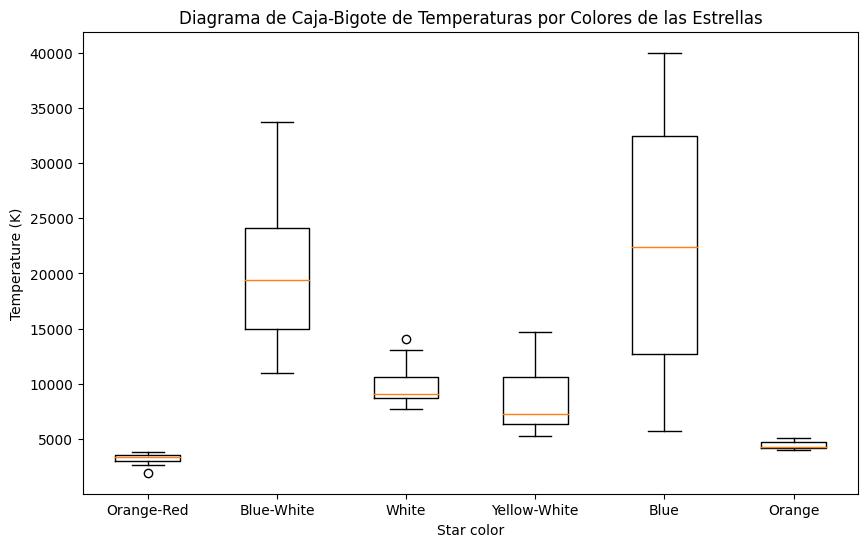

In [20]:
# Llamamos a la función que crea el diagrama
diagrama_caja_bigote()

Nos podemos dar cuenta que el trabajo dio frutos ya que eliminamos algunos valores atípicos y ahora tenemos más simétricos los datos para "Blue" y para "Blue-White" aunque todavía hace falta realizar otra gran depuración y esto es debido a que los rangos de las temperaturas todavía no están ajustados correctamente y se puede ver con facilidad en las cajas y los bigotes de, por ejemplo, "Blue", "Blue-White" y "Yellow-White"; y no sólo ahí sino que también el promedio de los valores de la temperatura sigue más o menos constante mostrando datos raros para ciertos colores.

Para realizar la segunda gran depuración se utiliza algo similar a lo que se trabajó previamente con el diccionario de mapeo solo que ahora con una lista llamada `condition`, en ella se guardarán todas las condiciones que se deben cumplir para que el filtro de los datos respecto a los rangos de temperatura en los que deben estar con base en su clase espectral. Luego con ayuda del método `np.logical_or.reduce()` lo que hace es trabajar todo ese montón de condiciones y reducirlas en una única condición compuesta la que será verdadera si alguna de las condiciones internas es verdadera, así se optimiza un poco más el trabajo ya que luego, se aplica es condición compuesta, llamada `combined_condition` en lo que sería el reemplazo del DataFrame `df`. Finalmente se vuelve a ajustar el indexado con `.reset_index()` y sus atributos `(drop=True, inplace=True)`.

In [21]:
conditions = [
    ((df['Spectral Class'] == 'O') & df['Temperature (K)'].between(28000, 50000)),
    ((df['Spectral Class'] == 'B') & df['Temperature (K)'].between(9900, 28000)),
    ((df['Spectral Class'] == 'A') & df['Temperature (K)'].between(7400, 9900)),
    ((df['Spectral Class'] == 'F') & df['Temperature (K)'].between(6000, 7400)),
    ((df['Spectral Class'] == 'K') & df['Temperature (K)'].between(3500, 4900)),
    ((df['Spectral Class'] == 'M') & df['Temperature (K)'].between(2000, 3500))
]
combined_condition = np.logical_or.reduce(conditions)
df = df[combined_condition]
df.reset_index(drop=True, inplace=True)

Tras haber realizado esta segunda gran depuración podemos volver a visualizar los datos con los dos métodos que hemos usado hasta ahora `.info()`, `.pivot_table()` y la función de la función que recrea la gráfica de caja-bigote.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         147 non-null    int64  
 1   Luminosity(L/Lo)        147 non-null    float64
 2   Radius(R/Ro)            147 non-null    float64
 3   Absolute magnitude(Mv)  147 non-null    float64
 4   Star type               147 non-null    int64  
 5   Star color              147 non-null    object 
 6   Spectral Class          147 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 8.2+ KB


In [23]:
df_panel_color = df.pivot_table(
    index=["Star color"],
    values=["Temperature (K)","Luminosity(L/Lo)","Radius(R/Ro)","Absolute magnitude(Mv)"],
    aggfunc="mean"
)
df_panel_color

,Absolute magnitude(Mv),Luminosity(L/Lo),Radius(R/Ro),Temperature (K)
Star color,,,,
Blue,-6.925000,380577.916667,646.565583,35946.916667
Blue-White,4.899500,72563.702320,230.835386,18385.400000
Orange,-10.295000,456000.000000,1424.500000,4151.000000
Orange-Red,12.143493,27026.669221,113.520517,3104.960000
White,6.417385,72504.131018,195.684385,8728.692308
Yellow-White,9.548000,0.556108,0.427200,6937.400000


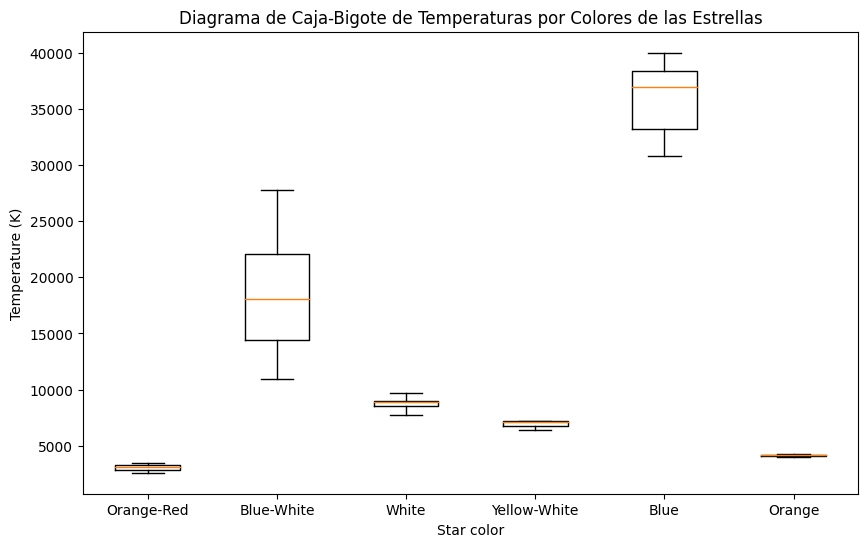

In [24]:
# Llamamos a la función que crea el diagrama
diagrama_caja_bigote()

Obteniendo así, ¡una reducción de **88 filas**!, esta depuración si estuvo un poco grande y eso se puede notar al ver el diagrama de caja-bigote, ahí nos podemos dar cuenta que los rangos ahora están bien establecidos y que no tenemos ni un solo dato atípico. También nos podemos fijar en la tabla dinámica `df_panel_color` la cual fue sobrescrita nuevamente y es que los promedios en la temperatura están concordes con los rangos establecidos en la tabla tomada de la literatura.

## Conclusión

Se realizó un análisis de los datos que se encuentran en el dataset *"Star dataset to predict star types"* donde el objetivo principal era dar uso a las tablas dinámicas que el método `.pivot_table()` nos podía dar, junto a afianzar otros conocimientos ya previos desarrollados a detalle en otras actividades. Si bien es cierto que a la hora de realizar todo el análisis de los datos nos fijamos únicamente en la relación entre el color de la estrella con su clase espectral y correspondientemente con su temperatura efectiva o superficial, esto no exime que también los datos en magnitud absoluta, radio, luminosidad y tipo de estrella estén erróneos o presentando comportamientos atípicos, pero no fue de especial interés ahora ya que por lo que se pudo investigar en la literatura, de los datos que teníamos los que más relación respecto a un catálogo del cual nos podamos guiar son esos que se trabajaron.